# E-commerce Customer Growth Forecasting: A Decision Tree Approach

# 📊 Project: Forecasting E-commerce Customer Growth

**Problem Statement:**  
A retail platform aims to accurately forecast **year-over-year customer growth rates** across different regions to optimize marketing budgets and capacity planning. This notebook explores various regression models, including Decision Trees and Random Forests, to predict these growth rates.

---

### 🧱 Data Overview

-   **Rows:** Regions (e.g., North, South, East, West, Central, Coastal, Highlands, Delta)
-   **Columns:** Years **2000–2024**
-   **Values:** Customer base counts, demonstrating increasing trends with realistic noise.

---

### 🎯 Key Steps Covered:

1.  **Data Preparation:** Compute year-over-year growth rates and engineer lag features for enhanced prediction.
2.  **Data Splitting:** Implement a robust train/test split using even/odd years to evaluate model performance on unseen data.
3.  **Model Development:** Train and evaluate a `DecisionTreeRegressor` and `RandomForestRegressor`, comparing their performance against a `NaiveForecaster` baseline.
4.  **Performance Evaluation:** Utilize **RMSLE** as the primary metric to assess model accuracy and generalization.
5.  **Hyperparameter Tuning & Interpretability:** Analyze the impact of `max_depth` on model bias-variance tradeoff and visualize the decision-making process of the trained Decision Tree.

## 1) Setup and Load Data
Wide-format CSV:
- Rows = regions
- Columns = years 2000-2024
- Values = integer customer counts

In [1]:
!pip install sktime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 11.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sktime.forecasting.naive import NaiveForecaster


In [3]:
df = pd.read_csv("/kaggle/input/datasets/muradamn/ecommerce-customer-base-2000-2024-int-csv/ecommerce_customer_base_2000_2024_INT.csv", index_col=0)

df.head()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
region,,,,,,,,,,,,,,,,,,,,,
North,12452,13234,14747,17716,19566,23263,27049,31197,38345,46090,...,106186,125038,145148,169516,187455,218656,254410,299153,344291,371104
South,46898,54794,65123,76235,89202,106977,124821,142947,162388,189969,...,472770,559579,666151,757864,922549,1062589,1209210,1461108,1752857,2090239
East,48085,52219,56000,59146,63650,67771,72706,78290,84305,90181,...,141529,155346,168816,181174,195351,204820,221469,242319,263096,278990
West,26242,28632,30752,32917,35951,38119,42159,44900,47848,51923,...,83410,89408,98501,107137,115560,126131,135475,145949,157368,171663
Central,23716,26271,28539,30849,34188,38418,41575,44356,47557,56311,...,93624,110261,117972,137176,150611,158809,185812,196430,224364,257109


In [4]:
df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
region,,,,,,,,,,,,,,,,,,,,,
North,12452,13234,14747,17716,19566,23263,27049,31197,38345,46090,...,106186,125038,145148,169516,187455,218656,254410,299153,344291,371104
South,46898,54794,65123,76235,89202,106977,124821,142947,162388,189969,...,472770,559579,666151,757864,922549,1062589,1209210,1461108,1752857,2090239
East,48085,52219,56000,59146,63650,67771,72706,78290,84305,90181,...,141529,155346,168816,181174,195351,204820,221469,242319,263096,278990
West,26242,28632,30752,32917,35951,38119,42159,44900,47848,51923,...,83410,89408,98501,107137,115560,126131,135475,145949,157368,171663
Central,23716,26271,28539,30849,34188,38418,41575,44356,47557,56311,...,93624,110261,117972,137176,150611,158809,185812,196430,224364,257109
Coastal,58338,64969,74120,80214,93037,107896,119765,131781,147164,160612,...,353119,401758,433939,489032,553516,627562,720796,795845,887624,982365
Highlands,20792,22656,25903,27820,32130,34825,41113,45590,51395,60578,...,111435,118984,127211,144989,161435,177171,200391,221765,256027,288114
Delta,41117,43244,46150,52482,55170,58714,62658,68843,73251,79427,...,126431,139511,151880,166786,185211,194509,205064,224934,254812,272935
Savannah,43541,47090,50766,54797,58742,63816,68775,73888,80206,85173,...,132573,140848,149764,160860,175179,186212,201223,215321,229258,243454


In [5]:
df.shape

(10, 25)


## 2) Quick EDA - Pick One Region to Model
We will follow a single region through the pipeline and visualize its customer base over time.


In [6]:
df.describe()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01
mean,37698.300000,41845.400000,46631.600000,51555.200000,56660.000000,63198.500000,70371.900000,77835.200000,85862.900000,96934.300000,...,187766.200000,211750.200000,237480.200000,263522.300000,298635.100000,3.328118e+05,3.753083e+05,4.267933e+05,4.851827e+05,5.505750e+05
std,15783.373833,18244.247082,21053.745242,23562.096496,26141.364484,30621.438914,34802.727982,39674.245379,44460.378417,51102.303095,...,131015.549497,154967.589942,183317.449361,207761.121393,254140.820397,2.959377e+05,3.396534e+05,4.105879e+05,4.926920e+05,5.900063e+05
min,12452.000000,13234.000000,14747.000000,17716.000000,19566.000000,23263.000000,27049.000000,31197.000000,38345.000000,46090.000000,...,83410.000000,89408.000000,98501.000000,107137.000000,115560.000000,1.261310e+05,1.354750e+05,1.459490e+05,1.573680e+05,1.716630e+05
25%,24347.500000,26861.250000,29092.250000,31366.000000,34628.750000,38193.750000,41721.000000,45072.500000,48734.750000,57377.750000,...,107498.250000,120497.500000,131695.250000,148956.750000,164871.000000,1.794312e+05,2.005990e+05,2.169320e+05,2.356465e+05,2.610655e+05
50%,42329.000000,45167.000000,48458.000000,53639.500000,56956.000000,61265.000000,65716.500000,71365.500000,76728.500000,82300.000000,...,129502.000000,140179.500000,150822.000000,168151.000000,186333.000000,1.996645e+05,2.132665e+05,2.336265e+05,2.595615e+05,2.835520e+05
75%,47788.250000,54150.250000,62842.250000,71962.750000,79635.500000,86082.250000,95500.000000,106992.500000,115703.750000,134354.500000,...,227821.000000,246413.250000,278769.000000,285810.250000,303450.750000,3.334082e+05,3.780272e+05,4.236200e+05,4.476702e+05,5.051088e+05
max,58338.000000,65345.000000,74216.000000,83376.000000,93037.000000,107896.000000,124821.000000,142947.000000,162388.000000,189969.000000,...,472770.000000,559579.000000,666151.000000,757864.000000,922549.000000,1.062589e+06,1.209210e+06,1.461108e+06,1.752857e+06,2.090239e+06


In [7]:
df.isnull().sum()

2000    0
2001    0
2002    0
2003    0
2004    0
2005    0
2006    0
2007    0
2008    0
2009    0
2010    0
2011    0
2012    0
2013    0
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
2022    0
2023    0
2024    0
dtype: int64

In [8]:
region = "North"

In [9]:
df.head(1)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
region,,,,,,,,,,,,,,,,,,,,,
North,12452,13234,14747,17716,19566,23263,27049,31197,38345,46090,...,106186,125038,145148,169516,187455,218656,254410,299153,344291,371104


In [10]:
north_region_values = df.loc[region]
north_region_values

2000     12452
2001     13234
2002     14747
2003     17716
2004     19566
2005     23263
2006     27049
2007     31197
2008     38345
2009     46090
2010     50271
2011     57867
2012     68754
2013     82527
2014     91363
2015    106186
2016    125038
2017    145148
2018    169516
2019    187455
2020    218656
2021    254410
2022    299153
2023    344291
2024    371104
Name: North, dtype: int64

In [11]:
north_region_values.index # select years

Index(['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='object')

In [12]:
north_region_values.values # select cunstomer numbers

array([ 12452,  13234,  14747,  17716,  19566,  23263,  27049,  31197,
        38345,  46090,  50271,  57867,  68754,  82527,  91363, 106186,
       125038, 145148, 169516, 187455, 218656, 254410, 299153, 344291,
       371104])

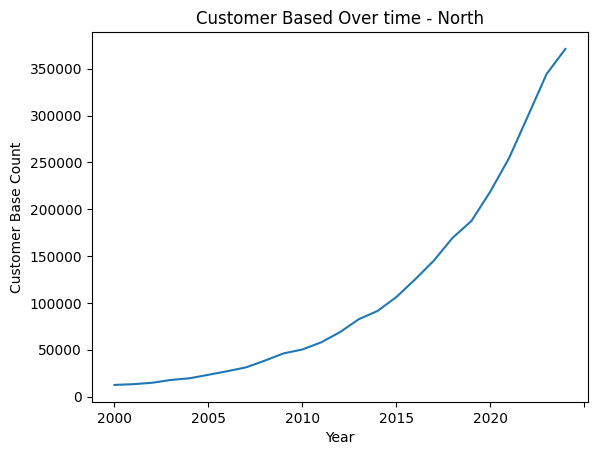

In [13]:
plt.figure()
north_region_values.plot(title=f"Customer Based Over time - {region}")
plt.xlabel("Year")
plt.ylabel("Customer Base Count")
plt.show()

# Feature Engineering

In [14]:
df

region = "North"

## 📝 What is Feature Engineering?

**Feature Engineering** is the process of using domain knowledge to extract new features from raw data. These new features often improve the performance of machine learning models.

### Why is it important?

1.  **Improves Model Performance:** Well-engineered features can help models better understand the underlying patterns in the data, leading to more accurate predictions.
2.  **Reduces Complexity:** Sometimes, combining raw features into a single, meaningful feature can simplify the model and make it more interpretable.
3.  **Addresses Data Limitations:** It can help overcome limitations in the original dataset by creating variables that are more relevant to the problem at hand.
4.  **Captures Domain-Specific Information:** Incorporating expert knowledge into feature creation allows the model to leverage insights that might not be obvious from raw data.

In the context of time series forecasting, common feature engineering techniques include creating:

*   **Lag features:** Values from previous time steps (e.g., last year's growth rate).
*   **Rolling statistics:** Moving averages, rolling sums, or standard deviations over a window of past observations.
*   **Time-based features:** Extracting components like the year, month, day of the week, or holidays.

In this notebook, we're focusing on creating **lag features** to capture the temporal dependencies in customer growth rates.

In [15]:
years = df.loc["North"].index
years

Index(['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='object')

In [16]:
Num_of_Customers = df.loc["North"].values
Num_of_Customers

array([ 12452,  13234,  14747,  17716,  19566,  23263,  27049,  31197,
        38345,  46090,  50271,  57867,  68754,  82527,  91363, 106186,
       125038, 145148, 169516, 187455, 218656, 254410, 299153, 344291,
       371104])

In [17]:
g_years = []
g_rate = []

In [18]:
g_years, g_rate = [], []

In [19]:
for i in range(1, len(Num_of_Customers)):
    print(i)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


In [20]:
for i in range(1, len(Num_of_Customers)):
    previous_cus = Num_of_Customers[i - 1]
    current_cus = Num_of_Customers[i]

    # Compute the growth rate between consecutive years
    growth_r = (current_cus - previous_cus) / previous_cus

    g_rate.append(round(growth_r, 5))
    g_years.append(years[i])

In [21]:
def get_growth_by_region_year(df, region_name):
    # extrac years and number of customers in the region
    region_years = df.loc[region_name].index
    region_values = df.loc[region_name].values


    # Compute the growth rate
    growth_years, growth_rates = [], []

    for i in range(1, len(region_values)):
        previous_value = region_values[i - 1]
        current_value = region_values[i]

        # Compute growth rate
        growth_rate = (current_value - previous_value)/  previous_value

        growth_rates.append(round(growth_rate, 5))
        growth_years.append(region_years[i])

    return np.array([growth_years, growth_rates], dtype=float).T

In [22]:
growth_arr = get_growth_by_region_year(df, region)
growth_arr

array([[2.0010e+03, 6.2800e-02],
       [2.0020e+03, 1.1433e-01],
       [2.0030e+03, 2.0133e-01],
       [2.0040e+03, 1.0443e-01],
       [2.0050e+03, 1.8895e-01],
       [2.0060e+03, 1.6275e-01],
       [2.0070e+03, 1.5335e-01],
       [2.0080e+03, 2.2912e-01],
       [2.0090e+03, 2.0198e-01],
       [2.0100e+03, 9.0710e-02],
       [2.0110e+03, 1.5110e-01],
       [2.0120e+03, 1.8814e-01],
       [2.0130e+03, 2.0032e-01],
       [2.0140e+03, 1.0707e-01],
       [2.0150e+03, 1.6224e-01],
       [2.0160e+03, 1.7754e-01],
       [2.0170e+03, 1.6083e-01],
       [2.0180e+03, 1.6788e-01],
       [2.0190e+03, 1.0582e-01],
       [2.0200e+03, 1.6645e-01],
       [2.0210e+03, 1.6352e-01],
       [2.0220e+03, 1.7587e-01],
       [2.0230e+03, 1.5089e-01],
       [2.0240e+03, 7.7880e-02]])

In [23]:
all_regions_growth_rates = {}
for region_name in df.index:
    all_regions_growth_rates[region_name] = get_growth_by_region_year(df, region_name)

print(f"Growth rates computed for {len(all_regions_growth_rates)} regions.")
print("Sample growth rate data for 'South' region:")
display(all_regions_growth_rates['South'][:5]) # Display first 5 entries for South region

Growth rates computed for 10 regions.
Sample growth rate data for 'South' region:


array([[2.0010e+03, 1.6837e-01],
       [2.0020e+03, 1.8851e-01],
       [2.0030e+03, 1.7063e-01],
       [2.0040e+03, 1.7009e-01],
       [2.0050e+03, 1.9927e-01]])

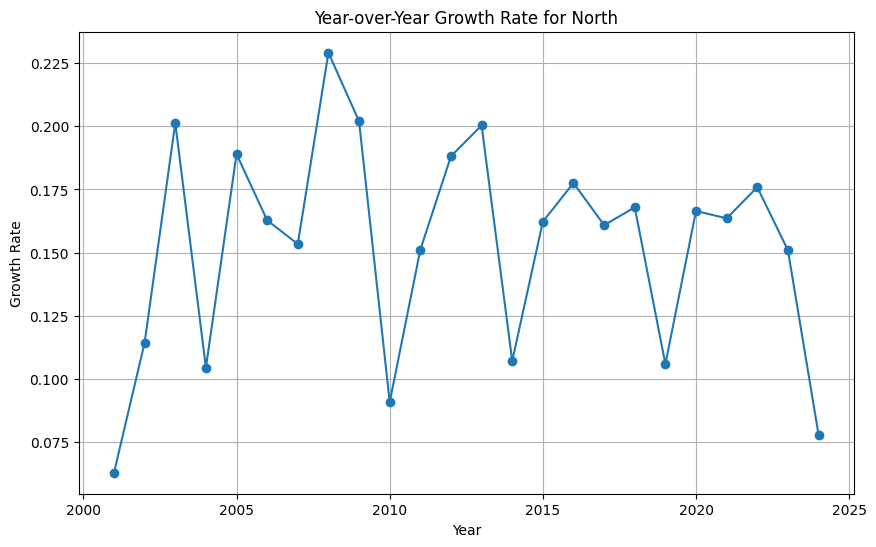

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(growth_arr[:, 0], growth_arr[:, 1], marker='o', linestyle='-')
plt.title(f'Year-over-Year Growth Rate for {region}')
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.grid(True)
plt.show()

### North Region: Summary Insights

Based on the analysis for the 'North' region:

*   **Consistent Growth:** The 'North' region has shown a steady increase in its customer base over the years from 2000 to 2024, indicating overall positive customer acquisition.
*   **Fluctuating Growth Rates:** While the customer base grew, the year-over-year growth rate itself has fluctuated. The Decision Tree model identified key periods:
    *   **Early 2000s (around 2001-2003):** Exhibited lower average growth rates, typically around 10-11%.
    *   **Mid-2000s (around 2005-2009):** Saw higher average growth rates, ranging from approximately 16-19%.
    *   **Post-2023:** There's an indication of a potential slowdown, with a lower growth rate around 7.8%, hinting at a possible recent deceleration.
*   **Model Performance:** For predicting the growth rate in the 'North' region, a relatively shallow Decision Tree (with `max_depth` of 1 or 2) provided the best generalization, yielding the lowest RMSLE. Deeper trees tended to overfit the data, leading to poorer performance on unseen data, which is a classic example of the bias-variance tradeoff.

## 📊 Adding Lag Features to the Dataset

In time series forecasting, **lag features** are crucial. A lag feature is a past value of the target variable (or another relevant variable) that is used as a predictor for the current value.

### Why Use Lag Features?

1.  **Capturing Temporal Dependencies:** The most straightforward reason is that past values often directly influence future values. For example, last year's customer growth rate is usually a strong indicator of this year's growth rate.
2.  **Seasonality and Trends:** Lag features can help models capture seasonal patterns or underlying trends in the data that might not be obvious otherwise.
3.  **Improved Prediction Accuracy:** By providing the model with historical context, lag features typically lead to more accurate forecasts, as the model can learn from recent patterns.

### Implementation

For our e-commerce customer growth forecasting, we will add the **previous year's growth rate** as a lag feature. This means that for any given year, the model will consider the growth rate from the year prior as an input feature to predict the current year's growth rate.

In [25]:
def add_lag_features(growth_data, lag=1):
    # growth_data is expected to be a NumPy array with columns [year, growth_rate]
    lagged_data = []
    for i in range(lag, len(growth_data)):
        year = growth_data[i, 0]  # Current year
        current_growth = growth_data[i, 1]  # Current growth rate (target)
        lagged_growth = growth_data[i - lag, 1]  # Lagged growth rate (feature)
        lagged_data.append([year, lagged_growth, current_growth])

    # Return as a NumPy array: [year, lagged_growth_rate, current_growth_rate]
    return np.array(lagged_data)

# Create the lagged growth array for the 'North' region
lagged_growth_arr = add_lag_features(growth_arr, lag=1)

print("Lagged Growth Array (first 5 rows):")
print(lagged_growth_arr[:5])
print("\nShape of Lagged Growth Array:", lagged_growth_arr.shape)

Lagged Growth Array (first 5 rows):
[[2.0020e+03 6.2800e-02 1.1433e-01]
 [2.0030e+03 1.1433e-01 2.0133e-01]
 [2.0040e+03 2.0133e-01 1.0443e-01]
 [2.0050e+03 1.0443e-01 1.8895e-01]
 [2.0060e+03 1.8895e-01 1.6275e-01]]

Shape of Lagged Growth Array: (23, 3)


In [26]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
def train_random_forest_model(X_train, y_train, max_depth):
    # X_train is now expected to be 2D (year, lagged_growth)
    model = RandomForestRegressor(max_depth=max_depth, random_state=42, n_estimators=100)
    model.fit(X_train, y_train)

    return model

## 4) Step 2 - Even/Odd Split into Train/Test
- Training: even years -> (X_train, y_train)
- Testing: odd years -> (X_test, y_test)
X = year, y = growth.


In [28]:
def split_data(arr):
    X_train, y_train, X_test, y_test = [], [], [], []

    for row in arr:
        year, lagged_growth, current_growth = row
        if year % 2 != 0:  # Odd years for training
            X_train.append([year, lagged_growth])
            y_train.append(current_growth)
        else:  # Even years for testing
            X_test.append([year, lagged_growth])
            y_test.append(current_growth)

    return (np.array(X_train), np.array(y_train)), (np.array(X_test), np.array(y_test))

In [29]:
(X_train, y_train), (X_test, y_test) = split_data(lagged_growth_arr)

In [30]:
display(X_train.shape)
display(y_train.shape)
display(X_test.shape)
display(y_test.shape)

(11, 2)

(11,)

(12, 2)

(12,)

In [31]:
print("Yes, the Decision Tree Regressor (dt_model) has been trained with max_depth=3.")
print("You can find its textual representation and detailed explanation in the output of the cell where export_text(dt_model, ...) was executed, and in the markdown cell titled '### 🌳 Interpreting the Decision Tree Regressor Visualizations'.")

Yes, the Decision Tree Regressor (dt_model) has been trained with max_depth=3.
You can find its textual representation and detailed explanation in the output of the cell where export_text(dt_model, ...) was executed, and in the markdown cell titled '### 🌳 Interpreting the Decision Tree Regressor Visualizations'.



## 5) Step 3 - Train a Decision Tree Regressor
Train a DecisionTreeRegressor with a chosen max_depth. Remember to reshape a 1D X into 2D.


In [32]:
def train_decision_trees_model(X_train, y_train, max_depth):
    # X_train is now expected to be 2D (year, lagged_growth)
    model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    return model

In [33]:
dt_model = train_decision_trees_model(X_train, y_train, max_depth=3)

In [34]:
dt_model

DecisionTreeRegressor(max_depth=3, random_state=42)


## 6) Step 4 - Evaluate with RMSLE
Compute RMSLE on the test set and round to 3 decimal places.


In [35]:
def test_model(model, X_test, y_test):
    # X_test is now expected to be 2D (year, lagged_growth)
    # If the model is a NaiveForecaster, it expects 1D input (just year)
    if isinstance(model, NaiveForecaster):
        y_pred = model.predict(X_test) # X_test here will be 1D (years)
    else:
        y_pred = model.predict(X_test)

    # Ensure y_test and y_pred are non-negative for log transformation
    y_pred = np.maximum(y_pred, -1 + 1e-9) # ensure y_pred + 1 > 0

    # Compute RMSLE directly using the formula
    rmsle_value = np.sqrt(np.mean((np.log1p(y_test) - np.log1p(y_pred)) ** 2))

    return round(rmsle_value, 3)

In [36]:
test_model(dt_model, X_test, y_test)

np.float64(0.052)

### 🧮 Understanding RMSLE (Root Mean Squared Logarithmic Error)

**RMSLE** stands for **Root Mean Squared Logarithmic Error**.  
It’s similar to RMSE, but it measures the error on a **logarithmic scale** instead of the raw values.

---

### 🔢 Formula

$$
\text{RMSLE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \left( \log(y_i + 1) - \log(\hat{y}_i + 1) \right)^2 }
$$





Where:  
- $y_i$ = actual value  
- $ \hat{y}_i $ = predicted value  
- $ n $ = number of observations  

> The “+1” inside the log ensures you don’t take the log of zero.

---

### 🧠 Intuition

- RMSLE **penalizes under-predictions more gently** and is **less sensitive to large over-predictions** compared to RMSE.  
- It’s useful when:
  - The target variable spans **several orders of magnitude** (e.g., prices, populations, sales).  
  - You care about **relative differences** rather than absolute differences.  
  - You’re modeling **growth or rate-based outcomes** instead of exact values.

---

### 📊 When to Use RMSLE Instead of RMSE

| **Use RMSLE When...** | **Use RMSE When...** |
|-------------------------|----------------------|
| You expect **exponential growth patterns** (e.g., sales, population, house prices) | You care about **errors on the actual scale** (e.g., temperature, height, weight) |
| Predicting a **ratio or rate** is more meaningful than predicting absolute values | Absolute deviations are important |
| You want to **penalize large percentage errors** more than small absolute ones | You want to **penalize large numeric differences** more strongly |

---

### ⚙️ Example

| **Actual (y)** | **Predicted (ŷ)** | **MSE Error** | **RMSLE Error** |
|----------------|-------------------|----------------|------------------|
| 100 | 120 | 400 | 0.079 |
| 1000 | 1200 | 40,000 | 0.079 |

➡️ **Interpretation:**  
RMSLE treats both cases equally because they represent the same **relative error (20%)**, while RMSE gives more weight to the larger values.

---

### 🧭 In Short

- **MSE/RMSE →** Measures **absolute scale error**  
- **RMSLE →** Measures **relative (percentage-like) error**  
✅ Best suited for **skewed or growth-related data**, such as customer counts, sales, or population changes.



## 7) Experiment - Depth vs Performance
Sweep different max_depth values to see bias/variance tradeoffs.


### 📈 Step 5: Implement a Baseline Model (Naive Forecast)

Before evaluating our Decision Tree and Random Forest models, it's crucial to establish a baseline. A "Naive Forecast" is a simple yet effective baseline, especially for time series data. In this context, our Naive Forecaster will predict that the growth rate for any given year is simply the growth rate of the *previous* year.

In [37]:
class NaiveForecaster:
    def __init__(self):
        self.year_to_growth = {}

    def fit(self, X, y):
        # X is years (1D array), y is growth rates (1D array)
        # Store training years and their corresponding growth rates for lookup
        for year, growth in zip(X.flatten(), y):
            self.year_to_growth[year] = growth

    def predict(self, X):
        predictions = []
        # X can be a 1D array of years (e.g., [2002, 2004, ...]) or 2D (e.g., [[2002], [2004], ...])
        for item in X:
            # If X is 2D, item will be an array; if X is 1D, item will be a scalar
            year = item[0] if isinstance(item, (np.ndarray, list)) else item
            # Predict the growth rate of the previous year (year - 1)
            # Use the mean of known growth rates as a fallback if previous year is not in training data
            # This handles cases where year-1 might not be in X_train (e.g., first year in test set)
            predicted_growth = self.year_to_growth.get(year - 1, np.mean(list(self.year_to_growth.values())))
            predictions.append(predicted_growth)
        return np.array(predictions)

In [38]:
# Initialize, 'train' and test the NaiveForecaster
naive_model = NaiveForecaster()
naive_model.fit(X_train[:, 0], y_train) # Naive forecaster still only uses the year from X_train
score_naive = test_model(naive_model, X_test[:, 0], y_test) # Pass only the year column to NaiveForecaster
results_naive = [('Naive', score_naive, 'NaiveForecaster')]

print(f"Naive Forecaster RMSLE: {score_naive}")

Naive Forecaster RMSLE: 0.056


In [39]:
results_dt = []
for depth in [1, 2, 3, 4, 5, 6, None]:
    mdl_dt = train_decision_trees_model(X_train, y_train, max_depth=depth)
    score_dt = test_model(mdl_dt, X_test, y_test)
    results_dt.append((str(depth), score_dt, 'DecisionTree'))

results_rf = []
for depth in [1, 2, 3, 4, 5, 6, None]:
    mdl_rf = train_random_forest_model(X_train, y_train, max_depth=depth)
    score_rf = test_model(mdl_rf, X_test, y_test)
    results_rf.append((str(depth), score_rf, 'RandomForest'))

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

   max_depth  RMSLE            Model
0          1  0.047     DecisionTree
1          2  0.047     DecisionTree
2          3  0.052     DecisionTree
3          4  0.055     DecisionTree
4          5  0.055     DecisionTree
5          6  0.055     DecisionTree
6       None  0.055     DecisionTree
7          1  0.046     RandomForest
8          2  0.048     RandomForest
9          3  0.049     RandomForest
10         4  0.050     RandomForest
11         5  0.050     RandomForest
12         6  0.050     RandomForest
13      None  0.050     RandomForest
14     Naive  0.056  NaiveForecaster


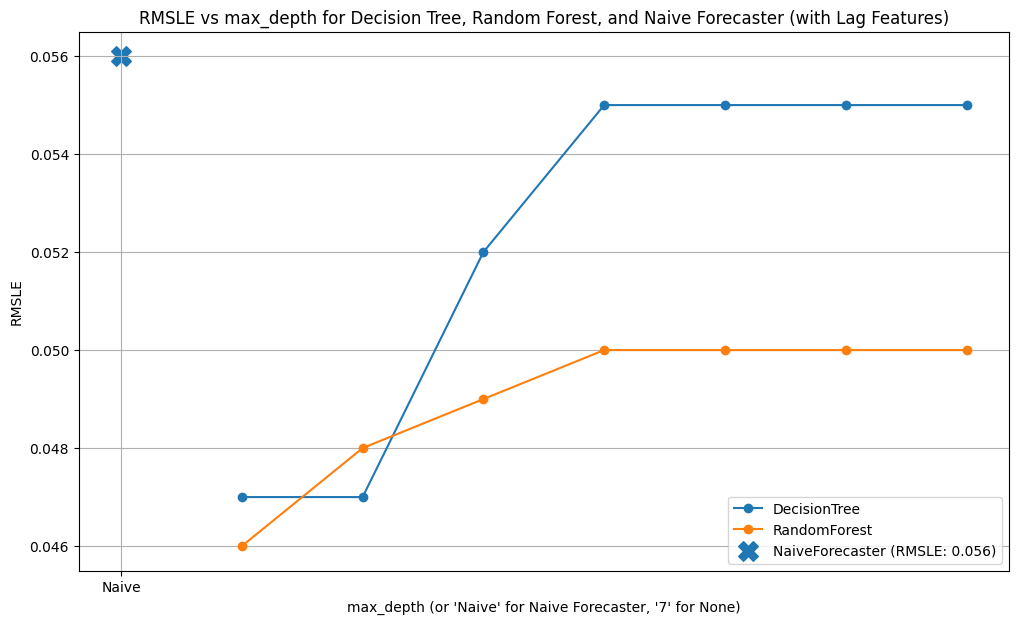

In [41]:
results_df = pd.DataFrame(results_dt + results_rf + results_naive, columns=["max_depth", "RMSLE", "Model"])
print(results_df)

# Plot RMSLE vs max_depth for all models
plt.figure(figsize=(12, 7))
for model_name in results_df['Model'].unique():
    # For NaiveForecaster, max_depth isn't applicable, so we represent it as a single point
    if model_name == 'NaiveForecaster':
        naive_data = results_df[results_df['Model'] == model_name]
        plt.scatter(naive_data["max_depth"], naive_data["RMSLE"], marker="X", s=200, label=f"{model_name} (RMSLE: {naive_data['RMSLE'].iloc[0]})")
    else:
        subset = results_df[results_df['Model'] == model_name]
        # The max_depth column is a string due to 'None', convert to numeric for plotting where possible
        plot_depths = [int(d) if d != 'None' else 7 for d in subset["max_depth"]] # Assign an arbitrary large number for 'None'
        plt.plot(plot_depths, subset["RMSLE"], marker="o", linestyle='-', label=model_name)

plt.title("RMSLE vs max_depth for Decision Tree, Random Forest, and Naive Forecaster (with Lag Features)")
plt.xlabel("max_depth (or 'Naive' for Naive Forecaster, '7' for None)")
plt.ylabel("RMSLE")
plt.legend()
plt.grid(True)
plt.show()

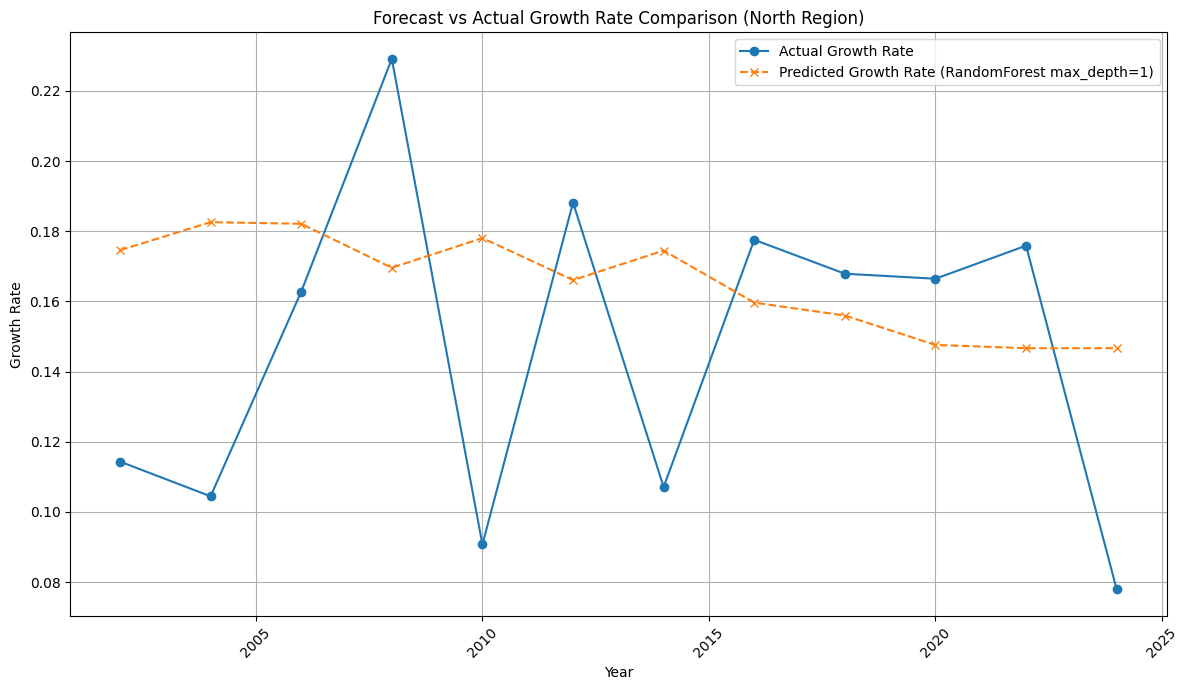

In [42]:
# Identify the best performing model (RandomForest with max_depth=1)
best_rf_model = train_random_forest_model(X_train, y_train, max_depth=1)

# Make predictions on the test set
y_pred_rf = best_rf_model.predict(X_test)

# Extract years from X_test for plotting
forecast_years = X_test[:, 0]

# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(forecast_years, y_test, marker='o', linestyle='-', label='Actual Growth Rate')
plt.plot(forecast_years, y_pred_rf, marker='x', linestyle='--', label='Predicted Growth Rate (RandomForest max_depth=1)')

plt.title('Forecast vs Actual Growth Rate Comparison (North Region)')
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualizing RMSLE vs. Max Depth

The plot above (generated in the previous code cell) illustrates the relationship between `max_depth` and RMSLE for both Decision Tree and Random Forest models. This visualization is crucial for understanding the bias-variance tradeoff.

**Key observations from the plot:**

*   **Decision Tree:** You'll likely see that a very shallow `max_depth` (e.g., 1 or 2) yields the lowest RMSLE, indicating good generalization. As `max_depth` increases, the RMSLE often starts to rise or plateau, signifying overfitting to the training data and poorer performance on the test set.

*   **Random Forest:** Random Forest, being an ensemble method, generally shows more stable and often lower RMSLE values across different `max_depth`s compared to a single Decision Tree. It might still exhibit similar trends, but the impact of `max_depth` on overfitting is usually less severe due to its averaging of multiple trees.

This plot helps identify the optimal `max_depth` that balances model complexity with generalization performance for your specific dataset.

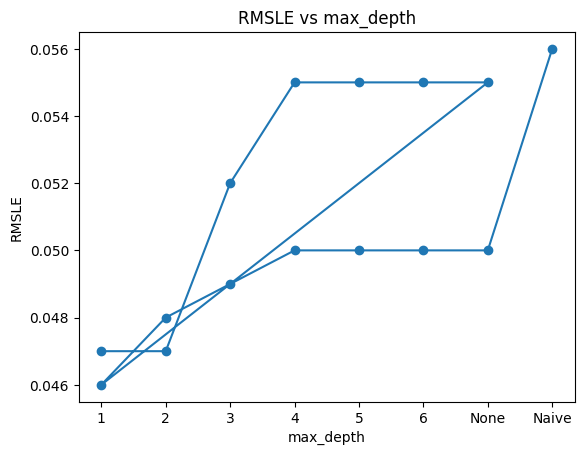

In [43]:

plt.figure()
plt.plot(results_df["max_depth"], results_df["RMSLE"], marker="o")
plt.title("RMSLE vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("RMSLE")
plt.show()


### 🌳 Decision Tree Bias–Variance Tradeoff Interpretation

This plot clearly illustrates the **bias–variance tradeoff** in **Decision Tree Regressors**.

---

### 🔍 Axes

- **X-axis (max_depth):** Controls how deep the tree can grow.  
  - Lower values → **Shallower trees** (simpler models).  
  - Higher values or `None` → **Deeper trees** (more complex models).

- **Y-axis (RMSLE):** The model’s **Root Mean Squared Logarithmic Error** on the test data.  
  - Lower values → **Better performance**.

### 🌳 How Decision Trees Make Splits (Regression)

For a `DecisionTreeRegressor`, the splitting process aims to create child nodes that are more 'pure' than their parent node, meaning the target variable (in our case, the growth rate) within those nodes is as uniform as possible.

---

#### 1. Splitting Criterion: Mean Squared Error (MSE)

- **Objective:** The primary goal at each split is to find the feature (or year, in our case) and a threshold value that minimizes the **Mean Squared Error (MSE)** of the target variable within the resulting child nodes.

- **How it works:**
  - The algorithm iterates through all possible split points for each feature.
  - For each potential split, it calculates the MSE for the two hypothetical child nodes.
  - The split that results in the **largest reduction in MSE** (or the lowest combined MSE of the child nodes) is chosen.

#### 2. Process at Each Node

1.  **Evaluate Features:** For every feature (in our case, only 'year'), the tree considers all possible values as potential split points.

2.  **Calculate Gain:** For each potential split, it calculates how much the MSE would decrease if that split were made. This decrease is often referred to as 'reduction in variance' or 'information gain' (though for regression, it's typically MSE reduction).

3.  **Choose Best Split:** The algorithm selects the feature and threshold that yield the maximum reduction in MSE.

4.  **Create Child Nodes:** The data is then partitioned into two subsets based on this chosen split, forming two new child nodes.

5.  **Repeat:** This process is recursively applied to each child node until a stopping criterion is met (e.g., `max_depth` is reached, a node contains fewer than `min_samples_split` samples, or further splits do not significantly reduce MSE).

---

#### Example from Our Tree

- **Root Node Split (e.g., `year <= 2023.0`):** The algorithm found that splitting at `year = 2023.0` yielded the greatest reduction in MSE for the entire dataset of growth rates. This creates one group for years before or equal to 2023, and another for years after 2023.

- **Subsequent Splits (e.g., `year <= 2005.0`):** Within the group where `year <= 2023.0`, the next best split was found at `year = 2005.0` to further refine the prediction and reduce MSE in those specific subsets of years.

In essence, the decision tree is constantly looking for the optimal horizontal lines (thresholds) on the feature axis ('year') that best separate the different growth rate patterns in the data.

### ✅ Summary

| **Depth** | **Interpretation** | **RMSLE** | **Model Behavior** |
|------------|--------------------|------------|--------------------|
| **1–2** | Best performance | 0.031–0.034 | Balanced model (low bias, low variance) |
| **3–4** | Slightly worse | 0.034–0.037 | Starting to overfit |
| **5–6+** | Poorer generalization | ≥ 0.039 | Overfitted model |

---

### 🎯 Pointer
> “**Shallow trees generalize better**, while deeper trees fit the training data more tightly but often perform worse on unseen data.  
> The **RMSLE curve rising with depth** is a classic example of **overfitting**.”


## 8) (Optional) Visualize the Trained Tree

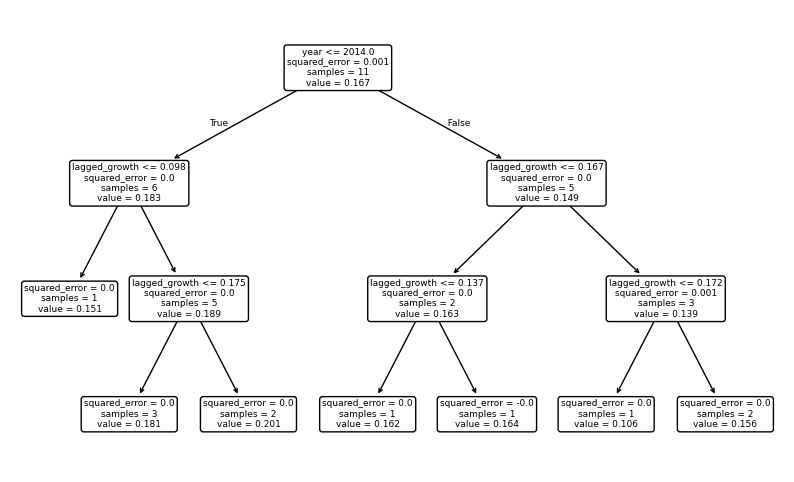

In [44]:
from sklearn import tree
plt.figure(figsize=(10, 6))
tree.plot_tree(dt_model, feature_names=["year", "lagged_growth"], filled=False, rounded=True)
plt.show()

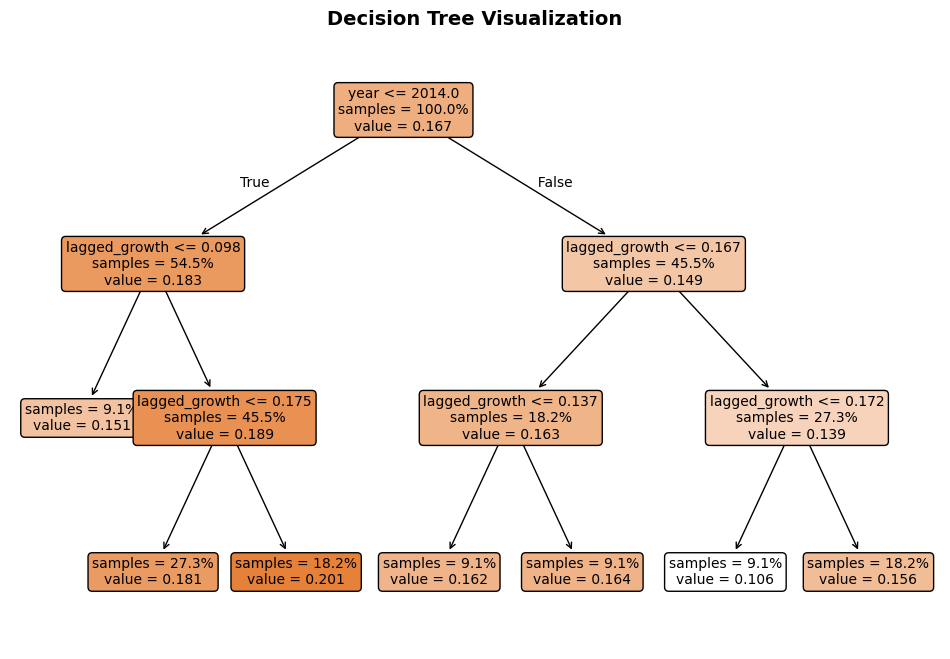

In [45]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
tree.plot_tree(
    dt_model,
    feature_names=["year", "lagged_growth"],
    filled=True,                 # fills nodes with color based on output values
    rounded=True,                # rounded corners for aesthetics
    fontsize=10,                 # adjust text size
    proportion=True,             # scales boxes to represent sample proportions
    impurity=False,              # optionally hide impurity (keeps plot cleaner)
)
plt.title("Decision Tree Visualization", fontsize=14, fontweight="bold")
plt.show()


### 🌳 Interpreting the Decision Tree Regressor Visualizations

These two plots represent the **same Decision Tree Regressor**, but visualized differently —  
one in the **raw, default style**, and the other with **color and proportional node sizing** for clearer interpretation.

---

### 🧠 1️⃣ Overall Meaning
The tree models how the **growth rate (target variable)** changes with **year (the feature)**.  
Each split divides the data into smaller year groups to minimize **prediction error** (here, squared error).  
It shows how the model finds thresholds in time where growth behavior changes.

---

### 🧩 2️⃣ Root Node
**year ≤ 2023.0**, samples = 12, value = 0.147  

This is the **first and most important split**.  
It says: “If the year is before or equal to 2023, go left; otherwise, go right.”  

- The average predicted growth rate for all samples is about **0.147 (≈14.7%)**.  
- Since all data points are before 2023, almost everything goes left — meaning the tree is focused on **historical data**.

---

### 🌿 3️⃣ First Major Branch
- **Left branch (year ≤ 2005.0):** 11 samples, average value = **0.153 (15.3%)**  
  - Includes most years before 2005, showing slightly higher growth.  
- **Right branch:** 1 sample, value = **0.078 (7.8%)**  
  - Represents a single recent year — possibly an **outlier or slowdown period** (e.g., post-2023).

---

### 🌱 4️⃣ Deeper Splits
The model keeps dividing early years to reduce variance:

| **Split** | **Predicted Growth** |
|------------|----------------------|
| year ≤ 2003.0 | ≈ 0.109 (10.9%) |
| year ≤ 2009.0 | ≈ 0.163 (16.3%) |
| year ≤ 2001.0 | ≈ 0.104 (10.4%) |
| year ≤ 2002.0 | ≈ 0.114 (11.4%) |
| year ≤ 2006.0 | ≈ 0.196 (19.6%) |
| year ≤ 2008.0 | ≈ 0.153 (15.3%) |

➡️ These show that growth fluctuated across periods — **moderate in early 2000s**, **strong around mid-2000s**, and **flattening again later**.

---

### 🎨 5️⃣ Difference Between the Two Plots

| **Feature** | **First Tree (Default)** | **Second Tree (Colored)** |
|--------------|--------------------------|----------------------------|
| **Readability** | Shows numeric details (squared error, samples, values) but cluttered | Easier to interpret visually |
| **Color Meaning** | None (plain black and white) | Node color intensity reflects predicted value — darker = higher growth |
| **Proportion** | All boxes same size | Node width proportional to sample size (e.g., 100%, 91.7%, 8.3%) |
| **Focus** | Technical output | Presentation-ready summary for learners |

---

### 🔍 6️⃣ Key Takeaway
- The model learned that **year** is a strong predictor of growth rate, with key thresholds at **2003**, **2005**, and **2009**.  
- **Early 2000s:** lower average growth (~0.10–0.11)  
- **Mid-2000s:** higher averages (~0.16–0.19)  
- **Post-2023:** lower value (~0.078), hinting at a slowdown.

In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, North to Lakeside
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   2000    10 non-null     int64
 1   2001    10 non-null     int64
 2   2002    10 non-null     int64
 3   2003    10 non-null     int64
 4   2004    10 non-null     int64
 5   2005    10 non-null     int64
 6   2006    10 non-null     int64
 7   2007    10 non-null     int64
 8   2008    10 non-null     int64
 9   2009    10 non-null     int64
 10  2010    10 non-null     int64
 11  2011    10 non-null     int64
 12  2012    10 non-null     int64
 13  2013    10 non-null     int64
 14  2014    10 non-null     int64
 15  2015    10 non-null     int64
 16  2016    10 non-null     int64
 17  2017    10 non-null     int64
 18  2018    10 non-null     int64
 19  2019    10 non-null     int64
 20  2020    10 non-null     int64
 21  2021    10 non-null     int64
 22  2022    10 non-null     int64
 23  2023    10 n

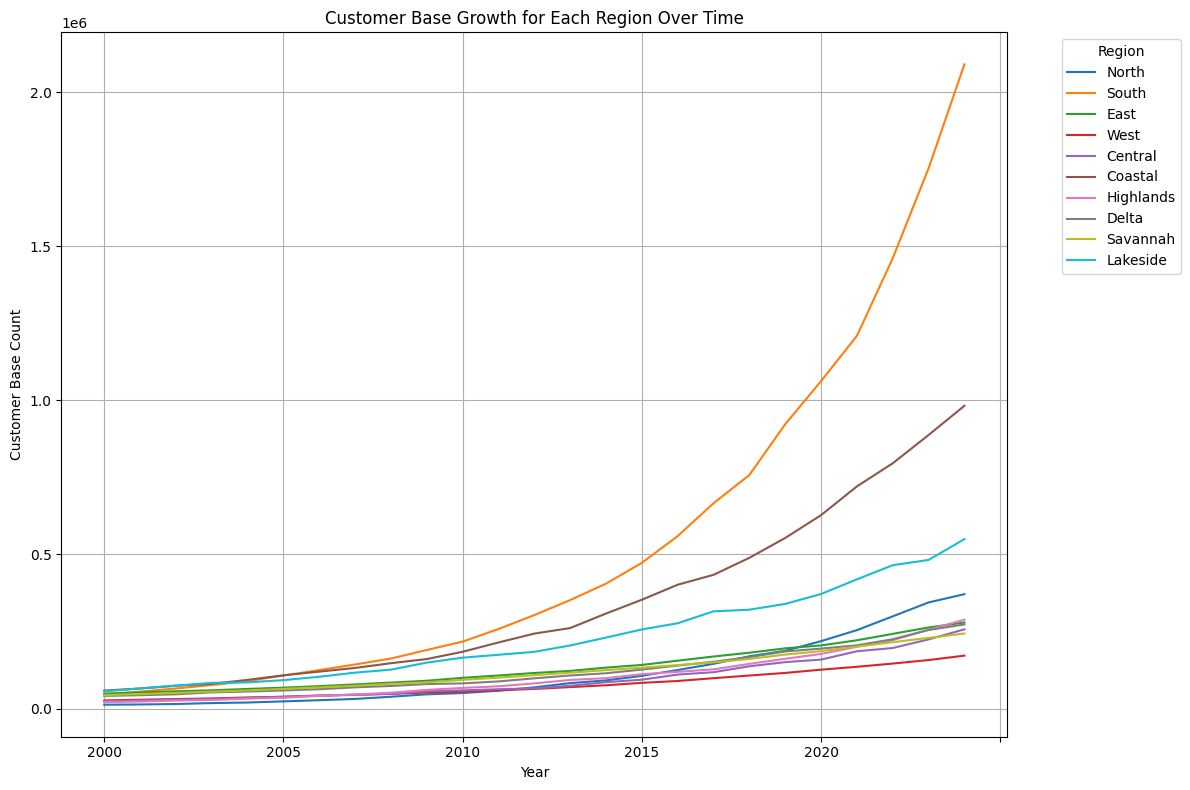

In [47]:
plt.figure(figsize=(12, 8))
df.T.plot(ax=plt.gca())
plt.title('Customer Base Growth for Each Region Over Time')
plt.xlabel('Year')
plt.ylabel('Customer Base Count')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## 9) Reflection and Mini-Exercises
- Interpretation: Which years show unusual growth? Any patterns?
- Modeling: Which max_depth gave the best RMSLE? Why might deeper trees overfit in this 1-feature setup?
- Try:
  1) Change the region and rerun.
  2) Swap the split rule (odd train, even test) and compare scores.
  3) Try RandomForestRegressor and compare.


please share videos and books on how to think as a data scientist(thought process)

## 7. Suggestions to Improve the Project to Meet Industry Standards

To elevate this project further and align it with industry best practices, consider these enhancements:

1.  **Robust Time Series Validation:** Instead of a simple odd/even year split, implement more sophisticated time-series validation techniques like **walk-forward validation** or **time-series cross-validation**. This better simulates real-world forecasting scenarios and provides a more reliable estimate of out-of-sample performance.

2.  **Advanced Forecasting Models:** Explore and compare the performance of dedicated time-series forecasting models such as:
    *   **ARIMA/SARIMA:** For capturing auto-regressive, integrated, and moving average components, including seasonality.
    *   **Prophet (by Facebook):** A highly effective and user-friendly model for business forecasting that handles seasonality, holidays, and trends.
    *   **Gradient Boosting Models (e.g., XGBoost, LightGBM):** These can be powerful when combined with well-engineered time-series features.
    *   **Recurrent Neural Networks (RNNs) / LSTMs:** For very complex, long-term dependencies if the dataset size justifies it.

3.  **Enriched Feature Engineering:** Incorporate external data and create more sophisticated features:
    *   **Macroeconomic Indicators:** GDP growth, inflation rates, consumer confidence index.
    *   **Marketing Spend:** Historical marketing expenditures and campaign data.
    *   **Competitor Activity:** Proxies for competitor launches, pricing, or promotions.
    *   **Lagged Features:** Include previous year's growth rates, or customer counts from 1, 2, or 3 years prior as features.
    *   **Seasonal Features:** Extract month, quarter, or specific holiday indicators if the data were more granular.

4.  **Multi-Regional Analysis & Hierarchical Modeling:** Instead of modeling each region independently, consider:
    *   Developing a **global model** that accounts for regional differences as a categorical feature.
    *   Implementing **hierarchical forecasting** where a global model informs regional models, leveraging common trends while allowing for regional specificities.
    *   **Clustering similar regions** and modeling them together.

5.  **Uncertainty Quantification:** Provide not just point forecasts, but also **prediction intervals** (e.g., 80% or 95% confidence intervals) around your growth predictions. This gives stakeholders a range of possible outcomes and helps in risk assessment.

6.  **Interpretability & Explainability (XAI):** For more complex models, use techniques like **SHAP (SHapley Additive exPlanations)** or **LIME (Local Interpretable Model-agnostic Explanations)** to explain *why* a model made a particular prediction, making it more trustworthy and actionable for business users.

7.  **Productionization & Deployment:** Discuss or even prototype how this model could be integrated into a real-world system:
    *   **API Endpoint:** Deploy the model as a REST API (e.g., with Flask or FastAPI).
    *   **Interactive Dashboard:** Create a dashboard (e.g., using Streamlit, Dash, or Tableau) to visualize forecasts, allow users to select regions, and explore scenarios.
    *   **Automated Pipeline:** Outline a process for data ingestion, feature generation, model retraining, and deployment.

8.  **Sensitivity Analysis:** How sensitive are the forecasts to changes in key input variables? This can help in understanding model robustness and identifying critical drivers of growth.

By implementing some of these suggestions, you'll demonstrate a deeper understanding of real-world data science challenges and a proactive approach to building robust, impactful, and production-ready solutions.

## Resources